## 03_Validation_DCA_SHAP
### Validation, Calibration, DCA, SHAP Interpretation

In [ ]:
# 导入包
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, f1_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve,CalibratedClassifierCV

import shap

plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [39]:
# 文件夹
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 加载模型与数据
best_models = joblib.load(r"D:\人工智能与生物应用学导论\项目作业\results_bph_ap\results_bph_ap\best_models.pkl")
predictions = joblib.load(r"D:\人工智能与生物应用学导论\项目作业\results_bph_ap\results_bph_ap\predictions.pkl")
data_split = joblib.load(r"D:\人工智能与生物应用学导论\项目作业\results_bph_ap\results_bph_ap\data_split.pkl")
X_test = data_split["X_test"]
y_test = data_split["y_test"]

🔄 正在进行安全的 Isotonic 概率校准（基于5折CV）...
✅ 安全校准完成！无数据泄露风险。


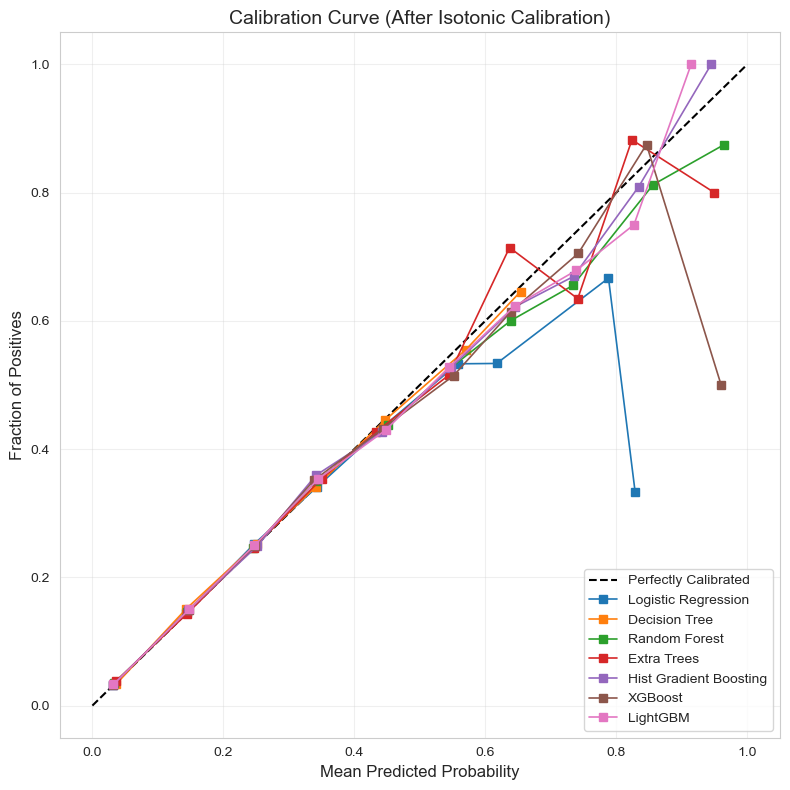

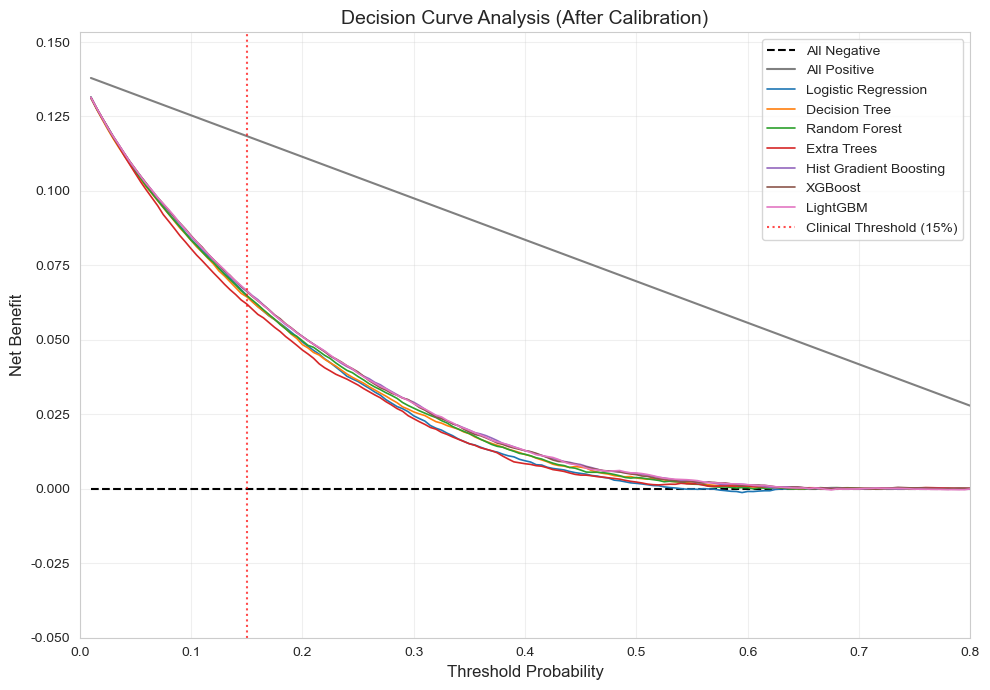

In [ ]:
# 概率校准
print("🔄 正在进行安全的 Isotonic 概率校准（基于5折CV）...")
calibrated_predictions = {}
uncalibrated_predictions = {}

for name, model in best_models.items():
    # 1. 保存未校准的原始测试集概率（用于后续对比）
    uncalibrated_predictions[name] = model.predict_proba(X_test)[:, 1]
    
    # 2. 使用 CalibratedClassifierCV 进行安全校准
    # cv=5 表示在训练集上做5折交叉验证生成样本外概率来拟合 isotonic
    # method='isotonic' 指定使用保序回归
    calibrated_model = CalibratedClassifierCV(
        estimator=model, 
        method='isotonic', 
        cv=5
    )
    
    # ⚠️ 注意：这里 fit 的是训练集，不是测试集！
    # 需要从 data_split 中获取 X_train 和 y_train
    X_train = data_split["X_train"]
    y_train = data_split["y_train"]
    
    calibrated_model.fit(X_train, y_train)
    
    # 3. 用校准后的模型在测试集上预测
    calibrated_predictions[name] = calibrated_model.predict_proba(X_test)[:, 1]

print("✅ 安全校准完成！无数据泄露风险。")

# 2. 绘制校准曲线 (使用校准后概率)
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", linewidth=1.5)

for name, y_prob_cal in calibrated_predictions.items():
    prob_true, prob_pred = calibration_curve(
        y_test, y_prob_cal, n_bins=10, strategy='uniform'
    )
    plt.plot(prob_pred, prob_true, 's-', label=name, linewidth=1.2)

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Fraction of Positives", fontsize=12)
plt.title("Calibration Curve (After Isotonic Calibration)", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/Calibration_Curve_Calibrated.png", dpi=300)
plt.show()


# 3. DCA 决策曲线分析 (使用校准后概率 + 优化显示)
def calculate_dca(y_true, y_prob, thresholds):
    """计算净收益，处理边界除零问题"""
    N = len(y_true)
    nb_values = []
    for pt in thresholds:
        if pt >= 1.0:
            nb_values.append(0.0)
            continue
        y_pred = (y_prob >= pt).astype(int)
        TP = ((y_pred == 1) & (y_true == 1)).sum()
        FP = ((y_pred == 1) & (y_true == 0)).sum()
        benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        nb_values.append(benefit)
    return nb_values

# 更密集的阈值步长，使曲线更平滑
thresholds = np.arange(0.01, 0.96, 0.005)
prevalence = y_test.mean()

plt.figure(figsize=(10, 7))

# 绘制参考基线
plt.plot(thresholds, np.zeros_like(thresholds), 'k--', label="All Negative", linewidth=1.5)
all_positive_line = prevalence * (1 - thresholds)
plt.plot(thresholds, all_positive_line, 'gray', label="All Positive", linewidth=1.5)

# 绘制各模型校准后的 DCA 曲线
for name, y_prob_cal in calibrated_predictions.items():
    nb = calculate_dca(y_test, y_prob_cal, thresholds)
    plt.plot(thresholds, nb, label=name, linewidth=1.2)

plt.xlabel("Threshold Probability", fontsize=12)
plt.ylabel("Net Benefit", fontsize=12)
plt.title("Decision Curve Analysis (After Calibration)", fontsize=14)
# 在 DCA 绘图后添加：
plt.axvline(0.15, color='red', linestyle=':', alpha=0.7, label="Clinical Threshold (15%)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 聚焦临床有效区域，避免极端阈值导致的图表失真
plt.ylim(-0.05, max(prevalence * 1.1, 0.15))
plt.xlim(0, 0.8)

plt.tight_layout()
plt.savefig("figures/DCA_Calibrated.png", dpi=300)
plt.show()

In [49]:
#  步骤1: 初始化两个核心字典
predictions_cal = {}
optimal_thresholds_cal = {}

print("🔧 正在构建校准概率与动态阈值字典...")

for name, model in best_models.items():
    # 获取测试集预测概率
    # 如果模型本身是 CalibratedClassifierCV，直接 predict_proba 即为校准后概率
    # 如果是原始模型，这里获取的是原始概率（需确保你已用其他方式校准并替换了 best_models 中的对象）
    prob = model.predict_proba(X_test)[:, 1]
    
    # 存入校准概率字典
    predictions_cal[name] = {"y_prob_cal": prob}
    
    # 基于校准后概率计算 Youden 最优阈值
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_thresholds_cal[name] = float(thresholds[optimal_idx])
    
    print(f"  ✔ {name:25s} | 校准后AUC={roc_auc_score(y_test, prob):.4f} | Youden阈值={optimal_thresholds_cal[name]:.4f}")

print("\n✅ 字典构建完成！")
print(f"   predictions_cal 包含 {len(predictions_cal)} 个模型")
print(f"   optimal_thresholds_cal 包含 {len(optimal_thresholds_cal)} 个阈值")

🔧 正在构建校准概率与动态阈值字典...
  ✔ Logistic Regression       | 校准后AUC=0.8196 | Youden阈值=0.4510
  ✔ Decision Tree             | 校准后AUC=0.8148 | Youden阈值=0.4792
  ✔ Random Forest             | 校准后AUC=0.8212 | Youden阈值=0.4665
  ✔ Extra Trees               | 校准后AUC=0.8097 | Youden阈值=0.5043
  ✔ Hist Gradient Boosting    | 校准后AUC=0.8270 | Youden阈值=0.4765
  ✔ XGBoost                   | 校准后AUC=0.8265 | Youden阈值=0.5089
  ✔ LightGBM                  | 校准后AUC=0.8272 | Youden阈值=0.4972

✅ 字典构建完成！
   predictions_cal 包含 7 个模型
   optimal_thresholds_cal 包含 7 个阈值


In [41]:
def ece_score(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    return np.mean(np.abs(prob_true - prob_pred))

for name, prob in calibrated_predictions.items():
    ece = ece_score(y_test, prob)
    print(f"{name:>15}: ECE = {ece:.4f}")

Logistic Regression: ECE = 0.0827
  Decision Tree: ECE = 0.0054
  Random Forest: ECE = 0.0298
    Extra Trees: ECE = 0.0435
Hist Gradient Boosting: ECE = 0.0230
        XGBoost: ECE = 0.0616
       LightGBM: ECE = 0.0294


In [ ]:
# 1. 基于已有的校准概率字典补算 Brier Score
brier_scores = {}
print("🔧 正在补算 Brier Score...")
for name, data in predictions_cal.items():
    prob_cal = data["y_prob_cal"]
    bs = brier_score_loss(y_test, prob_cal)
    brier_scores[name] = bs
    print(f"  ✔ {name:20s} | Brier Score = {bs:.4f}")

# 2. 转换为 DataFrame 并保存到本地
df_brier = pd.DataFrame({
    "Model": list(brier_scores.keys()),
    "Brier_Score": list(brier_scores.values())
}).sort_values("Brier_Score").reset_index(drop=True)

os.makedirs("results", exist_ok=True)
save_path = "results/brier_scores.csv"
df_brier.to_csv(save_path, index=False)

print(f"\n✅ Brier Score 已补算完成并保存至: {save_path}")
display(df_brier)

🔧 正在补算 Brier Score...
  ✔ Logistic Regression  | Brier Score = 0.1776
  ✔ Decision Tree        | Brier Score = 0.1815
  ✔ Random Forest        | Brier Score = 0.1763
  ✔ Extra Trees          | Brier Score = 0.1829
  ✔ Hist Gradient Boosting | Brier Score = 0.1755
  ✔ XGBoost              | Brier Score = 0.1760
  ✔ LightGBM             | Brier Score = 0.1752

✅ Brier Score 已补算完成并保存至: results/brier_scores.csv


,Model,Brier_Score
0,LightGBM,0.175242
1,Hist Gradient Boosting,0.175472
2,XGBoost,0.175959
3,Random Forest,0.176313
4,Logistic Regression,0.177578
5,Decision Tree,0.181508
6,Extra Trees,0.182922


Bootstrap ROC & PR
随机抽样 1000 次
输出均值 ± 标准差

In [42]:
# Bootstrap ROC & PR
n_bootstrap = 1000
rng = np.random.RandomState(42)

roc_results_cal = {}  # 重命名避免覆盖原始结果
pr_results_cal = {}

print("🔄 正在对校准后概率进行 Bootstrap 评估...")
for name in best_models.keys():
    y_prob_cal = calibrated_predictions[name]  # ✅ 关键修改
    aucs, aps = [], []
    
    for i in range(n_bootstrap):
        idx = rng.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_test.iloc[idx], y_prob_cal[idx]))
        aps.append(average_precision_score(y_test.iloc[idx], y_prob_cal[idx]))
        
    roc_results_cal[name] = (np.mean(aucs), np.std(aucs))
    pr_results_cal[name] = (np.mean(aps), np.std(aps))

# 保存校准后的性能指标
boot_cal_df = pd.DataFrame([
    {"Model": k, "AUC_mean": v[0], "AUC_std": v[1], 
     "AP_mean": pr_results_cal[k][0], "AP_std": pr_results_cal[k][1]}
    for k, v in roc_results_cal.items()
])
boot_cal_df.to_csv("results/Bootstrap_Calibrated.csv", index=False)
print("✅ 校准后 Bootstrap 完成")

🔄 正在对校准后概率进行 Bootstrap 评估...
✅ 校准后 Bootstrap 完成


阈值优化（临床决策阈值分析）
Youden Index
F1 最大值
输出 threshold_analysis.csv

In [ ]:
# Threshold optimization (F1 & Youden)
threshold_analysis_cal = []

for name in best_models.keys():
    y_prob_cal = calibrated_predictions[name] 
    
    # Youden
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob_cal)
    youden_idx = np.argmax(tpr - fpr)
    youden_thresh = roc_thresh[youden_idx]
    
    # F1
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob_cal)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    f1_idx = np.argmax(f1_scores)
    f1_thresh = pr_thresh[f1_idx] if f1_idx < len(pr_thresh) else 0.5
    
    threshold_analysis_cal.append([name, youden_thresh, f1_thresh])

threshold_cal_df = pd.DataFrame(
    threshold_analysis_cal, columns=["Model", "Youden_Threshold", "F1_Threshold"]
)
threshold_cal_df.to_csv("results/Threshold_Analysis_Calibrated.csv", index=False)
print("✅ 校准后最优阈值已保存")


✅ 校准后最优阈值已保存


🏆 最佳模型: Hist Gradient Boosting


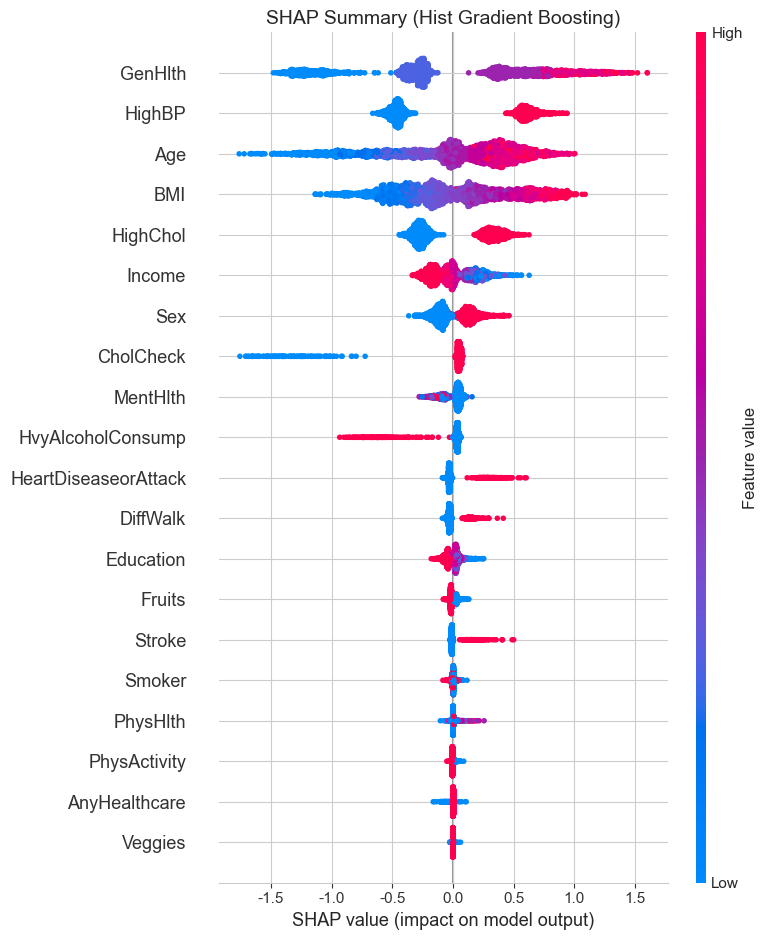

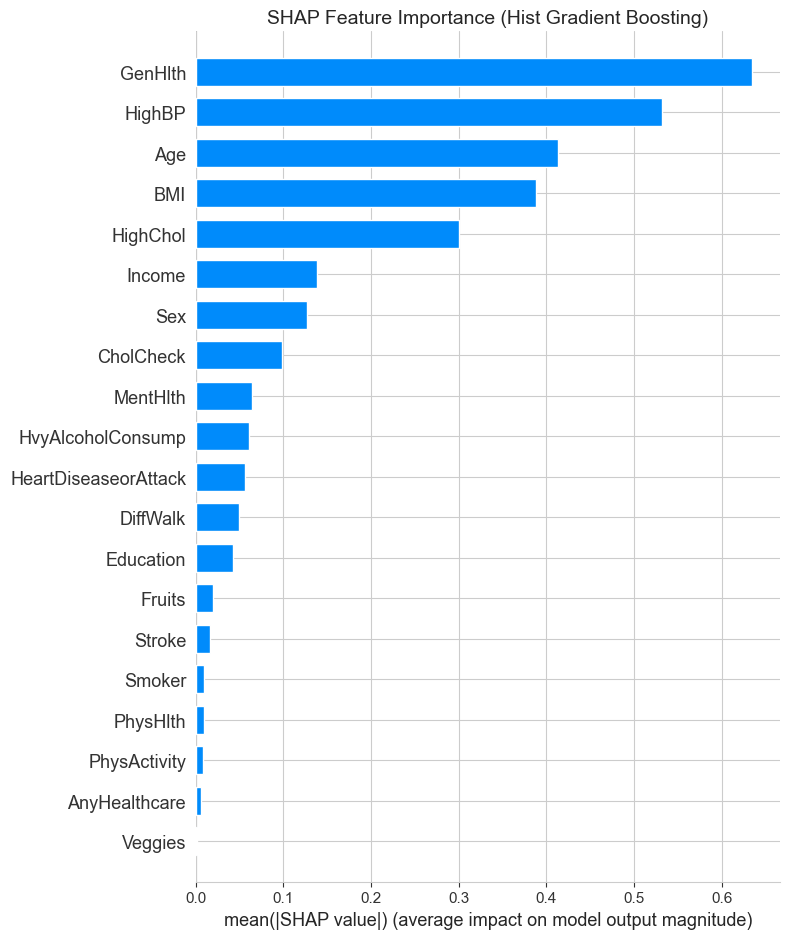


✅ Validation, Calibration, DCA, SHAP 完成。


In [ ]:
# SHAP Interpretation (仅最佳模型)
# 建议：使用校准后的AUC选择最佳模型（如果roc_results_cal存在）
best_model_name = max(roc_results_cal, key=lambda k: roc_results_cal[k][0])

    
print("🏆 最佳模型:", best_model_name)
best_model = best_models[best_model_name]

# 建议：固定随机种子，保证每次抽样的样本一致
rng = np.random.RandomState(42)
sample_size = min(3000, len(X_test))
sample_idx = rng.choice(len(X_test), sample_size, replace=False)
X_shap = X_test.iloc[sample_idx]

if hasattr(best_model, "predict_proba"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    
    # --- Beeswarm Plot ---
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.title(f"SHAP Summary ({best_model_name})", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/SHAP_Summary.png", dpi=300, bbox_inches='tight')
    plt.show()  # ✅ 关键：手动渲染到 Notebook
    plt.close()
    
    # --- Bar Plot ---
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance ({best_model_name})", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/SHAP_Bar.png", dpi=300, bbox_inches='tight')
    plt.show()  # ✅ 关键：手动渲染到 Notebook
    plt.close()
    
else:
    print("⚠️ 最佳模型不支持 SHAP 解释")

print("\n✅ Validation, Calibration, DCA, SHAP 完成。")

In [ ]:
# Bootstrap ΔAUC (使用校准后概率)
baseline_name = "Logistic Regression"
baseline_prob_cal = calibrated_predictions[baseline_name]  # ✅ 校准后的LR作为基线

auc_diff_cal = []
for name in best_models.keys():
    if name == baseline_name:
        continue
    model_prob_cal = calibrated_predictions[name]  # ✅ 校准后的目标模型
    delta_auc = []
    
    for i in range(n_bootstrap):
        idx = rng.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx])) < 2:
            continue
        auc1 = roc_auc_score(y_test.iloc[idx], model_prob_cal[idx])
        auc0 = roc_auc_score(y_test.iloc[idx], baseline_prob_cal[idx])
        delta_auc.append(auc1 - auc0)
        
    mean_diff = np.mean(delta_auc)
    ci_lower = np.percentile(delta_auc, 2.5)
    ci_upper = np.percentile(delta_auc, 97.5)
    p_value = (np.sum(np.array(delta_auc) <= 0) + 1) / (len(delta_auc) + 1)
    auc_diff_cal.append([name, mean_diff, ci_lower, ci_upper, p_value])

auc_diff_cal_df = pd.DataFrame(
    auc_diff_cal, columns=["Model vs LR", "ΔAUC", "CI_lower", "CI_upper", "P_value"]
)
auc_diff_cal_df.to_csv("results/Bootstrap_Delta_AUC_Calibrated.csv", index=False)
print("✅ 校准后 ΔAUC 已保存")

✅ 校准后 ΔAUC 已保存


In [ ]:
# NRI / IDI 
def calc_nri_idi(y_true, prob_new, prob_ref, threshold=0.5):
    """
    计算NRI和IDI 
    """
    y_true = np.array(y_true)
    prob_new = np.array(prob_new)
    prob_ref = np.array(prob_ref)
    
    # 二分类风险重分类
    reclass_up = (prob_new >= threshold) & (prob_ref < threshold)
    reclass_down = (prob_new < threshold) & (prob_ref >= threshold)
    
    # NRI
    event_idx = y_true == 1
    non_event_idx = y_true == 0
    nri_event = np.mean(reclass_up[event_idx]) - np.mean(reclass_down[event_idx])
    nri_nonevent = np.mean(reclass_down[non_event_idx]) - np.mean(reclass_up[non_event_idx])
    nri = nri_event + nri_nonevent
    
    # IDI
    idi = (np.mean(prob_new[event_idx]) - np.mean(prob_ref[event_idx])) - \
          (np.mean(prob_new[non_event_idx]) - np.mean(prob_ref[non_event_idx]))
    
    return nri, idi

nri_idi_results = []

for name in best_models.keys():
    if name == baseline_name:
        continue
        
    # 使用【校准后】的预测概率，而非原始概率
    prob_new_cal = predictions_cal[name]["y_prob_cal"] 
    baseline_prob_cal = predictions_cal[baseline_name]["y_prob_cal"]
    
    # 使用校准后的 Youden 最优阈值，而非硬编码 0.5
    current_threshold = optimal_thresholds_cal[name]
    
    nri, idi = calc_nri_idi(
        y_test, 
        prob_new_cal,      # 传入校准后新模型概率
        baseline_prob_cal, # 传入校准后基线概率
        threshold=current_threshold  # 传入动态阈值
    )
    nri_idi_results.append([name, round(nri, 4), round(idi, 4)])

nri_idi_df = pd.DataFrame(
    nri_idi_results,
    columns=["Model vs Baseline", "NRI", "IDI"]
)
nri_idi_df.to_csv("results/NRI_IDI.csv", index=False)
print("✅ NRI/IDI (基于校准后概率与Youden阈值) 已保存")
print(nri_idi_df)

✅ NRI/IDI (基于校准后概率与Youden阈值) 已保存
        Model vs Baseline     NRI     IDI
0           Decision Tree -0.0145  0.0046
1           Random Forest -0.0019 -0.0321
2             Extra Trees -0.0176 -0.0637
3  Hist Gradient Boosting  0.0122  0.0151
4                 XGBoost  0.0151  0.0171
5                LightGBM  0.0155  0.0187
